# Import Modules

In [ ]:
#pip install opencv-python

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
import PIL
import tensorflow as tf
import cv2 as cv2

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import pandas as pd

import pathlib

## Get Num of data per class

In [ ]:
sdir=r'./'
csvpath=r'./sports.csv'
df=pd.read_csv(csvpath)

# check for missing values
print('number of missing values in df is =', df.isna().sum().sum())
df.columns=['filepaths', 'labels',  'data_set']
train_df=df.query('data_set== "train"')
test_df=df.query('data_set== "test"')
valid_df = df.query('data_set== "valid"')

# convert data in filepaths column to the full path to the images
train_df['filepaths']=train_df['filepaths'].apply(lambda x: os.path.join(sdir, x))
test_df['filepaths']=test_df['filepaths'].apply(lambda x: os.path.join(sdir, x))
valid_df['filepaths']=valid_df['filepaths'].apply(lambda x: os.path.join(sdir, x))
print('train_df lenght: ', len(train_df), '  test_df length: ', len(test_df), '  valid_df length: ', len(valid_df),'\n')

# get the number of classes and the images count for each class in train_df
classes=list(train_df['labels'].unique())
class_count = len(classes)
print('The number of classes in the dataset is: ', class_count,'\n')
groups=train_df.groupby('labels')
print('{0:^30s} {1:^13s}'.format('CLASS', 'IMAGE COUNT'))
countlist=[]
classlist=[]
for label in train_df['labels'].unique():
    group=groups.get_group(label)
    countlist.append(len(group))
    classlist.append(label)
    print('{0:^30s} {1:^13s}'.format(label, str(len(group))))

# get the classes with the minimum and maximum number of train images
max_value=np.max(countlist)
max_index=countlist.index(max_value)
max_class=classlist[max_index]
min_value=np.min(countlist)
min_index=countlist.index(min_value)
min_class=classlist[min_index]
print(max_class, ' has the most images= ',max_value,'\n', min_class, ' has the least images= ', min_value)


number of missing values in df is = 0
train_df lenght:  13572   test_df length:  500   valid_df length:  500 

The number of classes in the dataset is:  100 

            CLASS               IMAGE COUNT 
          air hockey                112     
       ampute football              112     
           archery                  132     
        arm wrestling               99      
         axe throwing               113     
         balance beam               152     
        barell racing               123     
           baseball                 174     
          basketball                169     
        baton twirling              108     
          bike polo                 111     
          billiards                 145     
             bmx                    140     
           bobsled                  138     
           bowling                  120     
            boxing                  116     
         bull riding                149     
        bungee jumping         

In [ ]:
train_df

,filepaths,labels,data_set
0,./train/air hockey/001.jpg,air hockey,train
1,./train/air hockey/002.jpg,air hockey,train
2,./train/air hockey/003.jpg,air hockey,train
3,./train/air hockey/004.jpg,air hockey,train
4,./train/air hockey/005.jpg,air hockey,train
...,...,...,...
13567,./train/wingsuit flying/94.jpg,wingsuit flying,train
13568,./train/wingsuit flying/95.jpg,wingsuit flying,train
13569,./train/wingsuit flying/96.jpg,wingsuit flying,train
13570,./train/wingsuit flying/97.jpg,wingsuit flying,train


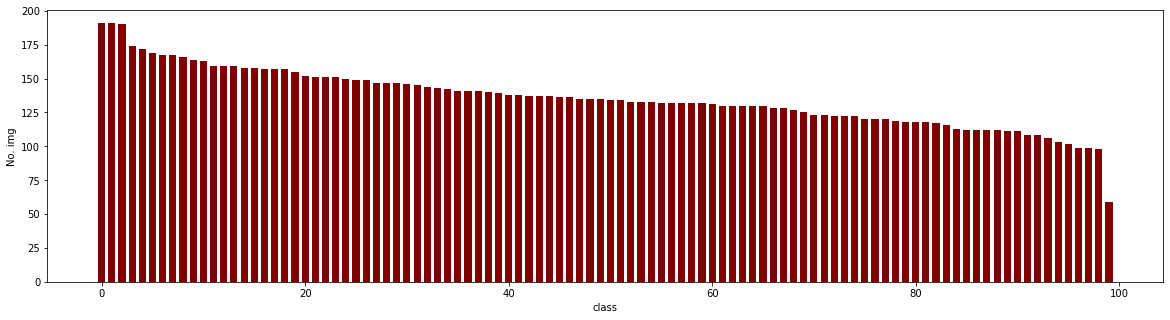

In [ ]:
fig = plt.figure(figsize = (20, 5))
 
# creating the bar plot
plt.bar(range(len(countlist)), sorted(countlist,reverse=True), color ='maroon',
        width = 0.7)
 
plt.xlabel("class")
plt.ylabel("No. img")
plt.show()

## Trim the df dataframe to max and min samples

In [ ]:
def trim(df, max_samples, min_samples):
    df=df.copy()
    groups=df.groupby('labels')    
    trimmed_df = pd.DataFrame(columns = df.columns)
    groups=df.groupby('labels')
    for label in df['labels'].unique(): 
        group=groups.get_group(label)
        count=len(group)    
        if count > max_samples:
            sampled_group=group.sample(n=max_samples, random_state=123,axis=0)
            trimmed_df=pd.concat([trimmed_df, sampled_group], axis=0)
        else:
            if count>=min_samples:
                sampled_group=group        
                trimmed_df=pd.concat([trimmed_df, sampled_group], axis=0)
    print('After trimming, the maximum samples in any class is now',max_samples, 'and the minimum samples in any class is', min_samples)
    return trimmed_df


max_samples=150
min_samples=50
train_df=trim(train_df, max_samples, min_samples)
train_df

After trimming, the maximum samples in any class is now 150 and the minimum samples in any class is 50


,filepaths,labels,data_set
0,./train/air hockey/001.jpg,air hockey,train
1,./train/air hockey/002.jpg,air hockey,train
2,./train/air hockey/003.jpg,air hockey,train
3,./train/air hockey/004.jpg,air hockey,train
4,./train/air hockey/005.jpg,air hockey,train
...,...,...,...
13567,./train/wingsuit flying/94.jpg,wingsuit flying,train
13568,./train/wingsuit flying/95.jpg,wingsuit flying,train
13569,./train/wingsuit flying/96.jpg,wingsuit flying,train
13570,./train/wingsuit flying/97.jpg,wingsuit flying,train


## Balance the dataset

In [ ]:
def balance(df, n, working_dir, img_size):
    df=df.copy()
     # make directories to store augmented images
    aug_dir=os.path.join(working_dir, 'aug')
    if os.path.isdir(aug_dir):
        shutil.rmtree(aug_dir) # start with an clean empty directory
    os.mkdir(aug_dir)
    for label in df['labels'].unique():    
        dir_path=os.path.join(aug_dir,label)    
        os.mkdir(dir_path)
    # create and store the augmented images  
    total=0
    gen=ImageDataGenerator(horizontal_flip=True,  rotation_range=20, width_shift_range=.2,
                                  height_shift_range=.2, zoom_range=.2)
    groups=df.groupby('labels') # group by class
    for label in df['labels'].unique():  # for every class               
        group=groups.get_group(label)  # a dataframe holding only rows with the specified label 
        sample_count=len(group)   # determine how many samples there are in this class  
        if sample_count< n: # if the class has less than target number of images
            aug_img_count=0
            delta=n - sample_count  # number of augmented images to create
            target_dir=os.path.join(aug_dir, label)  # define where to write the images
            msg='{0:40s} for class {1:^30s}'.format(' ', label)
            print(msg, '\r', end='') # prints over on the same line
            aug_gen=gen.flow_from_dataframe( group,  x_col='filepaths', y_col=None, target_size=img_size,
                                            class_mode=None, batch_size=1, shuffle=False, 
                                            save_to_dir=target_dir, save_prefix='aug-', color_mode='rgb',
                                            save_format='jpg')
            while aug_img_count<delta:
                images=next(aug_gen)            
                aug_img_count += len(images)
            total +=aug_img_count
    
    print('Total Augmented images created= ', total)
    # create aug_df and merge with train_df to create composite training set ndf
    if total>0:
        aug_fpaths=[]
        aug_labels=[]
        classlist=os.listdir(aug_dir)
        for klass in classlist:
            classpath=os.path.join(aug_dir, klass)     
            flist=os.listdir(classpath)    
            for f in flist:        
                fpath=os.path.join(classpath,f)         
                aug_fpaths.append(fpath)
                aug_labels.append(klass)
        Fseries=pd.Series(aug_fpaths, name='filepaths')
        Lseries=pd.Series(aug_labels, name='labels')
        aug_df=pd.concat([Fseries, Lseries], axis=1)        
        df=pd.concat([df,aug_df], axis=0).reset_index(drop=True)
    return df 

n=170 # number of samples in each class
working_dir=r'./' # directory to store augmented images
img_size=(224,224) # size of augmented images
train_df=balance(train_df, n, working_dir, img_size)

Found 112 validated image filenames.     for class           air hockey           
Found 112 validated image filenames.     for class        ampute football         
Found 132 validated image filenames.     for class            archery             
Found 99 validated image filenames.      for class         arm wrestling          
Found 113 validated image filenames.     for class          axe throwing          
Found 150 validated image filenames.     for class          balance beam          
Found 123 validated image filenames.     for class         barell racing          
Found 150 validated image filenames.     for class            baseball            
Found 150 validated image filenames.     for class           basketball           
Found 108 validated image filenames.     for class         baton twirling         
Found 111 validated image filenames.     for class           bike polo            
Found 145 validated image filenames.     for class           billiards            
Foun

In [ ]:
train_df['filepaths'] = train_df['filepaths'].apply(lambda x: x.lstrip("."))
train_df['filepaths'] = r"/content/drive/MyDrive/Colab Notebooks/comp5152" + train_df['filepaths']
valid_df['filepaths'] = valid_df['filepaths'].apply(lambda x: x.lstrip("."))
valid_df['filepaths'] = r"/content/drive/MyDrive/Colab Notebooks/comp5152" + valid_df['filepaths']
test_df['filepaths'] = test_df['filepaths'].apply(lambda x: x.lstrip("."))
test_df['filepaths'] = r"/content/drive/MyDrive/Colab Notebooks/comp5152" + test_df['filepaths']
train_df.to_csv('train_df.csv')
valid_df.to_csv('valid_df.csv')
test_df.to_csv('test_df.csv')